# **MÓDULO 39 - Exercicio - Aplicando XGboost**

Nessa atividade vocês usarão uma base já connhecida, a base de propensão a compra de carros.
Já utilizamos essa base antes, nessa atividade, você deve carregar a base, realizar os tratamentos necessários, rodar o XGBoost, encontrar as principais variaveis.
Vamos lá!

In [1]:
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# 1. Carrega a base de dados, verifique os tipos de dados, dados faltantes e drop a coluna ID.


In [2]:
# Importa o banco de dados
df = pd.read_csv('CARRO_CLIENTES.csv')
df

,User ID,Gender,Age,AnnualSalary,Purchased
0,385,Male,35,20000,0
1,681,Male,40,43500,0
2,353,Male,49,74000,0
3,895,Male,40,107500,1
4,661,Male,25,79000,0
...,...,...,...,...,...
995,863,Male,38,59000,0
996,800,Female,47,23500,0
997,407,Female,28,138500,1
998,299,Female,48,134000,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   User ID       1000 non-null   int64 
 1   Gender        1000 non-null   object
 2   Age           1000 non-null   int64 
 3   AnnualSalary  1000 non-null   int64 
 4   Purchased     1000 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 39.2+ KB


Observa-se que o dataframe é composto por cinco colunas, sendo quatro numéricas e uma categórica (string). Além disso, verifica-se a ausência de valores nulos ou faltantes em todas as colunas.

In [4]:
# Drop da coluna User ID
df = df.drop(columns='User ID')
df

,Gender,Age,AnnualSalary,Purchased
0,Male,35,20000,0
1,Male,40,43500,0
2,Male,49,74000,0
3,Male,40,107500,1
4,Male,25,79000,0
...,...,...,...,...
995,Male,38,59000,0
996,Female,47,23500,0
997,Female,28,138500,1
998,Female,48,134000,1


# 2. Aplique o Label Encoder para a coluna Gender e exclua a coluna categórica.

In [5]:
# Instancia o Label Encoder
label_encoder = LabelEncoder()

# Aplica na coluna Gender
df['Gender_encoded'] = label_encoder.fit_transform(df['Gender'])

# Exclui a coluna categórica
df = df.drop(columns='Gender')

# Ordena as colunas para a Gender_encoded ser a primeira
df = df[['Gender_encoded', 'Age', 'AnnualSalary', 'Purchased']]
df

,Gender_encoded,Age,AnnualSalary,Purchased
0,1,35,20000,0
1,1,40,43500,0
2,1,49,74000,0
3,1,40,107500,1
4,1,25,79000,0
...,...,...,...,...
995,1,38,59000,0
996,0,47,23500,0
997,0,28,138500,1
998,0,48,134000,1


# 3. Faça a matriz de correlação e analise as váriaveis que parecem ter maior correlação com a váriavel target.

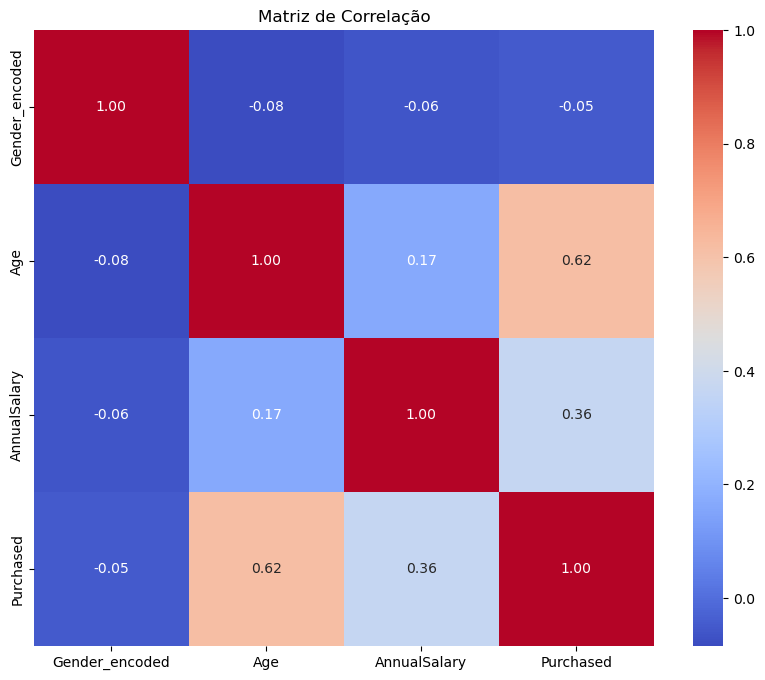

In [6]:
# Cria a matriz de correlação
correlation_matrix = df.corr()

# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

As variáveis que apresentam maior correlação com a variável alvo (`Purchased`) são `Age` e `AnnualSalary`. A variável `Age` possui uma correlação relativamente forte, de 0,62, enquanto `AnnualSalary` apresenta uma correlação moderada, de 0,36.

Por outro lado, a variável `Gender_encoded` não demonstra correlação significativa com a variável alvo, indicando que o gênero tem pouca ou nenhuma influência na previsão de `Purchased` neste conjunto de dados.

# 4. Faça a separação da base em X e Y e em seguida nas bases de treino e teste.

In [7]:
# Separação em X e Y
X = df.drop(columns='Purchased')
y = df['Purchased']

In [8]:
# Separação em treino e teste
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Treino o modelo Xgboost com sua base de treino.
Pesquise alguns hyperparametros na bibllioteca para utilizar, utilize ao menos 2.

In [9]:
# Instancia o modelo
model_xgboost = xgb.XGBClassifier(
    num_parallel_tree=5,   # Number of parallel trees constructed during each iteration.
    max_leaves=10   # Maximum number of nodes to be added.
)

In [10]:
# Treina o modelo
model_xgboost.fit(X_train,Y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=10, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=5, ...)

# 6. Realize as previsões para a base de teste e traga as probabilidades das previsões.

In [11]:
# Previsões das classes
Y_pred = model_xgboost.predict(X_test)

# Probabilidades de cada classe
Y_pred_prob = model_xgboost.predict_proba(X_test)

In [12]:
Y_pred_prob

array([[8.02995443e-01, 1.97004586e-01],
       [7.60049820e-02, 9.23995018e-01],
       [9.99898553e-01, 1.01462989e-04],
       [8.74485016e-01, 1.25514999e-01],
       [1.74375713e-01, 8.25624287e-01],
       [1.00310445e-02, 9.89968956e-01],
       [2.89022923e-04, 9.99710977e-01],
       [9.99734819e-01, 2.65171140e-04],
       [9.99572396e-01, 4.27574152e-04],
       [9.97980416e-01, 2.01958278e-03],
       [9.85012293e-01, 1.49877062e-02],
       [9.99877691e-01, 1.22317622e-04],
       [9.56800103e-01, 4.31998968e-02],
       [9.99755144e-01, 2.44850205e-04],
       [9.18340683e-03, 9.90816593e-01],
       [7.61609674e-02, 9.23839033e-01],
       [4.81664062e-01, 5.18335938e-01],
       [8.68120193e-02, 9.13187981e-01],
       [3.74895334e-02, 9.62510467e-01],
       [9.99765456e-01, 2.34562380e-04],
       [9.99308407e-01, 6.91606780e-04],
       [2.35325098e-03, 9.97646749e-01],
       [1.03796721e-02, 9.89620328e-01],
       [9.99895036e-01, 1.04945204e-04],
       [3.216266

# 7. Faça a transformação das probabilidades nas previsões binárias e avalie o desempenho do modelo.

In [13]:
# Previsões binárias da variável target
Y_pred

array([0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 1])

In [14]:
# Avalia o modelo
accuracy = accuracy_score(Y_test, Y_pred)
report = classification_report(Y_test, Y_pred)
conf_matrix = confusion_matrix(Y_test, Y_pred)

print(f'Acurácia: {accuracy}')
print('Relatório de Classificação:')
print(report)
print('Matriz de Confusão:')
print(conf_matrix)

Acurácia: 0.885
Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       112
           1       0.88      0.85      0.87        88

    accuracy                           0.89       200
   macro avg       0.88      0.88      0.88       200
weighted avg       0.88      0.89      0.88       200

Matriz de Confusão:
[[102  10]
 [ 13  75]]


A matriz de confusão mostra que o modelo obteve um bom desempenho na classificação das duas classes. Dos 112 casos pertencentes à classe 0, 102 foram classificados corretamente e apenas 10 foram incorretamente identificados como classe 1. Já para a classe 1, o modelo classificou corretamente 75 dos 88 casos, cometendo 13 erros.

No total, o modelo realizou 177 classificações corretas e 23 incorretas, resultando em uma acurácia de aproximadamente 88,5%. Além disso, observa-se um equilíbrio entre os erros de falsos positivos (10) e falsos negativos (13), indicando que o modelo não apresenta uma tendência forte de favorecer uma classe em detrimento da outra.

# 8. Traga a lista com a feature importance.
As features mais importantes são as mesmas que indicaram maior correlação na matriz de correlação?

In [15]:
# Pega a importancia das features
importances = model_xgboost.get_booster().get_score(importance_type='gain')

# Convertendo o dicionário de importâncias para um DataFrame
importance_df = pd.DataFrame(list(importances.items()), columns=['Feature', 'Importance'])
importance_df['Importance'] = importance_df['Importance'].astype(float)
importance_df = importance_df.sort_values(by='Importance', ascending=False)

importance_df

,Feature,Importance
1,Age,2.896279
2,AnnualSalary,1.657389
0,Gender_encoded,0.530094


Segundo o modelo XGBoost, as variáveis mais importantes para a previsão da variável alvo (`Purchased`) são `Age` e `AnnualSalary`, respectivamente.

Esse resultado é particularmente interessante, pois corrobora as conclusões obtidas anteriormente por meio da matriz de correlação. Nela, observou-se que `Age` apresentava a maior correlação com a variável alvo, seguida por `AnnualSalary`. Dessa forma, a análise de importância das variáveis realizada pelo XGBoost reforça a relevância dessas duas características para o processo de previsão.